# Notebook 04: Descriptive Analysis

## Project: GlucoVision Analytics

This notebook focuses on descriptive analysis of the cleaned and preprocessed diabetes glucose dataset.

The goal is to summarize glucose patterns, patient-level differences, risk categories, and dashboard-ready metrics.

This notebook supports:
- Descriptive analysis
- Prescriptive analysis preparation
- Streamlit dashboard development

### 2. Import Libraries

Why this step is important

Libraries are required for loading data, summarizing values, and creating visualizations.

Consequences if skipped

The notebook will not be able to read files, calculate metrics, or generate charts.

In [4]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### 3. Professional Chart Styling

Why this step is important

Consistent styling makes charts easier to read and gives the notebook a professional appearance.

Consequences if skipped

Charts may look inconsistent and less suitable for a portfolio or dashboard project.

In [5]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="tab10"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

### 4. Load Processed Data

Why this step is important

Descriptive analysis should be performed on cleaned and preprocessed data.

Consequences if skipped

Using raw data may produce inaccurate or unreliable insights.

In [6]:
DATA_DIR = "../data/processed"

main_data_path = os.path.join(DATA_DIR, "glucovision_cleaned_preprocessed.csv")
patient_summary_path = os.path.join(DATA_DIR, "patient_summary.csv")

df = pd.read_csv(main_data_path)
patient_summary = pd.read_csv(patient_summary_path)

print("Main dataset shape:", df.shape)
print("Patient summary shape:", patient_summary.shape)

Main dataset shape: (309392, 23)
Patient summary shape: (25, 9)


### 5. Confirm Data Types

Why this step is important

Time columns must be in datetime format for daily, hourly, and trend-based analysis.

Consequences if skipped

Time-based summaries and charts may not work correctly.

In [7]:
df["time"] = pd.to_datetime(df["time"])

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309392 entries, 0 to 309391
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   time                    309392 non-null  datetime64[us]
 1   glucose                 309392 non-null  float64       
 2   calories                309392 non-null  float64       
 3   heart_rate              309392 non-null  float64       
 4   steps                   309392 non-null  float64       
 5   basal_rate              309392 non-null  float64       
 6   bolus_volume_delivered  309392 non-null  float64       
 7   carb_input              309392 non-null  float64       
 8   patient_id              309392 non-null  str           
 9   time_diff               309367 non-null  str           
 10  is_low_glucose          309392 non-null  bool          
 11  is_high_glucose         309392 non-null  bool          
 12  glucose_category        309392 non-null  

## Section A: Dashboard KPI Summary
### 6. Create Overall KPI Metrics

Why this step is important

KPIs provide a high-level overview of the dataset and are useful for dashboard summary cards.

Consequences if skipped

The project may lack clear summary metrics for users or stakeholders.

Dashboard use

These values can be displayed as KPI cards in the Streamlit dashboard.

In [8]:
total_records = len(df)
total_patients = df["patient_id"].nunique()
average_glucose = df["glucose"].mean()
median_glucose = df["glucose"].median()
minimum_glucose = df["glucose"].min()
maximum_glucose = df["glucose"].max()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Patients",
        "Average Glucose",
        "Median Glucose",
        "Minimum Glucose",
        "Maximum Glucose"
    ],
    "Value": [
        total_records,
        total_patients,
        round(average_glucose, 2),
        round(median_glucose, 2),
        round(minimum_glucose, 2),
        round(maximum_glucose, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Records,309392.00
1,Total Patients,25.00
2,Average Glucose,141.43
3,Median Glucose,132.00
4,Minimum Glucose,40.00
5,Maximum Glucose,444.00


## Section B: Glucose Category Summary
### 7. Glucose Category Counts

Why this step is important

This shows how many glucose readings fall into each risk category.

Consequences if skipped

We may not understand how often patients experience normal, low, or high glucose readings.

Dashboard use

This chart can be used in a glucose risk summary tab.

In [9]:
glucose_category_counts = (
    df["glucose_category"]
    .value_counts()
    .reset_index()
)

glucose_category_counts.columns = ["glucose_category", "count"]

glucose_category_counts

,glucose_category,count
0,Normal,221892
1,High,67123
2,Low,20377


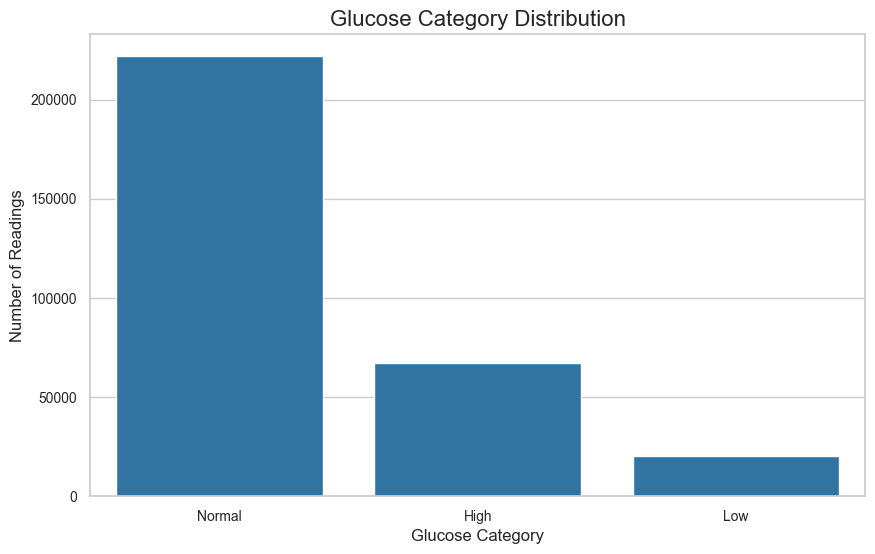

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=glucose_category_counts,
    x="glucose_category",
    y="count"
)

plt.title("Glucose Category Distribution")
plt.xlabel("Glucose Category")
plt.ylabel("Number of Readings")
plt.show()

## 8. Glucose Category Percentages

Why this step is important

Percentages make risk distribution easier to interpret than raw counts alone.

Consequences if skipped

Users may not understand the proportion of low or high glucose readings clearly.

In [11]:
glucose_category_percent = (
    df["glucose_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

glucose_category_percent.columns = ["glucose_category", "percentage"]

glucose_category_percent

,glucose_category,percentage
0,Normal,71.72
1,High,21.70
2,Low,6.59


## Section C: Time-Based Descriptive Analysis
### 9. Average Glucose by Hour

Why this step is important

This identifies whether glucose levels change throughout the day.

Consequences if skipped

We may miss time-of-day glucose patterns that could support recommendations.

Dashboard use

This can be used in a time-patterns dashboard tab.

In [12]:
hourly_glucose_summary = (
    df.groupby("hour")
    .agg(
        average_glucose=("glucose", "mean"),
        median_glucose=("glucose", "median"),
        min_glucose=("glucose", "min"),
        max_glucose=("glucose", "max"),
        reading_count=("glucose", "count")
    )
    .reset_index()
)

hourly_glucose_summary.head()

,hour,average_glucose,median_glucose,min_glucose,max_glucose,reading_count
0,0,142.560453,131.691542,40.0,438.000000,12842
1,1,138.743205,129.666667,40.0,404.000000,12852
2,2,137.456326,130.000000,40.0,416.333333,12852
3,3,138.166504,130.000000,40.0,430.000000,12852
4,4,139.117531,129.666667,40.0,444.000000,12852


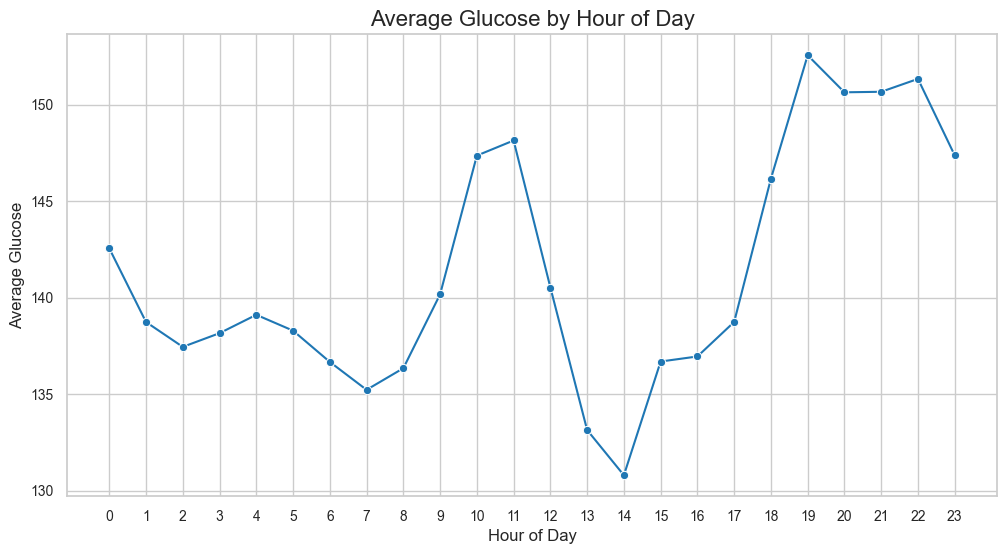

In [13]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_glucose_summary,
    x="hour",
    y="average_glucose",
    marker="o"
)

plt.title("Average Glucose by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Glucose")
plt.xticks(range(0, 24))
plt.show()

### 10. Average Glucose by Day of Week

Why this step is important

This helps summarize weekly glucose patterns.

Consequences if skipped

The project may miss recurring weekday or weekend glucose differences.

Dashboard use

This can support weekly glucose trend visualizations.

In [14]:
weekday_glucose_summary = (
    df.groupby("day_of_week")
    .agg(
        average_glucose=("glucose", "mean"),
        median_glucose=("glucose", "median"),
        min_glucose=("glucose", "min"),
        max_glucose=("glucose", "max"),
        reading_count=("glucose", "count")
    )
    .reset_index()
)

weekday_glucose_summary

,day_of_week,average_glucose,median_glucose,min_glucose,max_glucose,reading_count
0,Friday,143.302473,134.000000,40.0,415.0,44829
1,Monday,145.633648,137.333333,40.0,406.0,43955
2,Saturday,142.852699,131.616766,40.0,444.0,44857
3,Sunday,141.781830,132.000000,40.0,416.0,44060
4,Thursday,138.730195,129.000000,40.0,443.5,44825
5,Tuesday,139.678462,131.000000,40.0,438.0,44271
6,Wednesday,137.884933,130.333333,40.0,367.0,42595


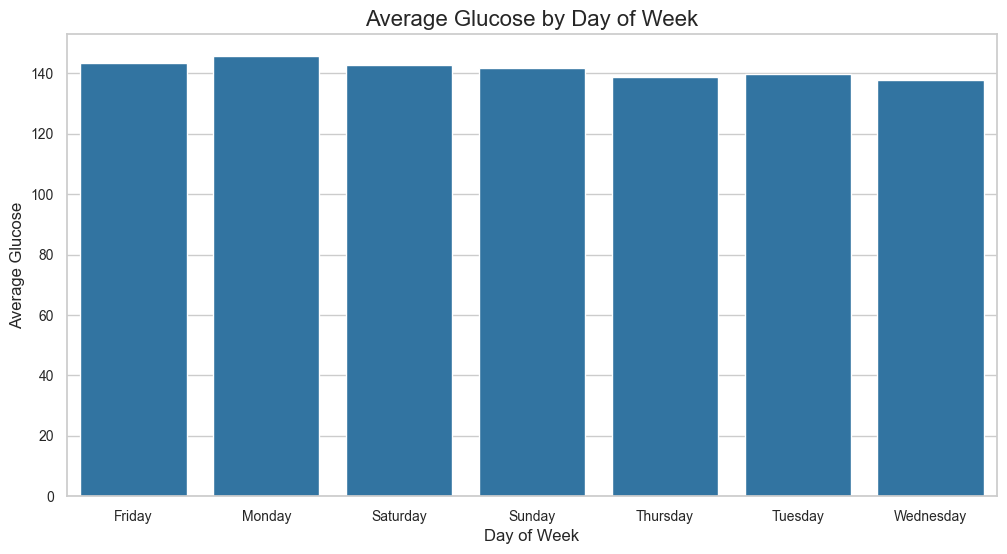

In [15]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=weekday_glucose_summary,
    x="day_of_week",
    y="average_glucose"
)

plt.title("Average Glucose by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Glucose")
plt.show()

### 11. Daily Average Glucose Trend

Why this step is important

Daily trend analysis shows how glucose levels change over time.

Consequences if skipped

Long-term glucose patterns may be missed.

Dashboard use

This can be used in a glucose trend dashboard tab.

In [16]:
daily_glucose_summary = (
    df.groupby("date")
    .agg(
        average_glucose=("glucose", "mean"),
        median_glucose=("glucose", "median"),
        min_glucose=("glucose", "min"),
        max_glucose=("glucose", "max"),
        reading_count=("glucose", "count")
    )
    .reset_index()
)

daily_glucose_summary.head()

,date,average_glucose,median_glucose,min_glucose,max_glucose,reading_count
0,2018-06-13,146.688474,129.000000,40.0,332.0,107
1,2018-06-14,138.313079,139.833333,40.0,300.0,864
2,2018-06-15,166.699157,146.000000,52.0,366.0,864
3,2018-06-16,138.562417,127.333333,40.0,294.0,864
4,2018-06-17,154.510417,143.000000,58.0,310.0,864


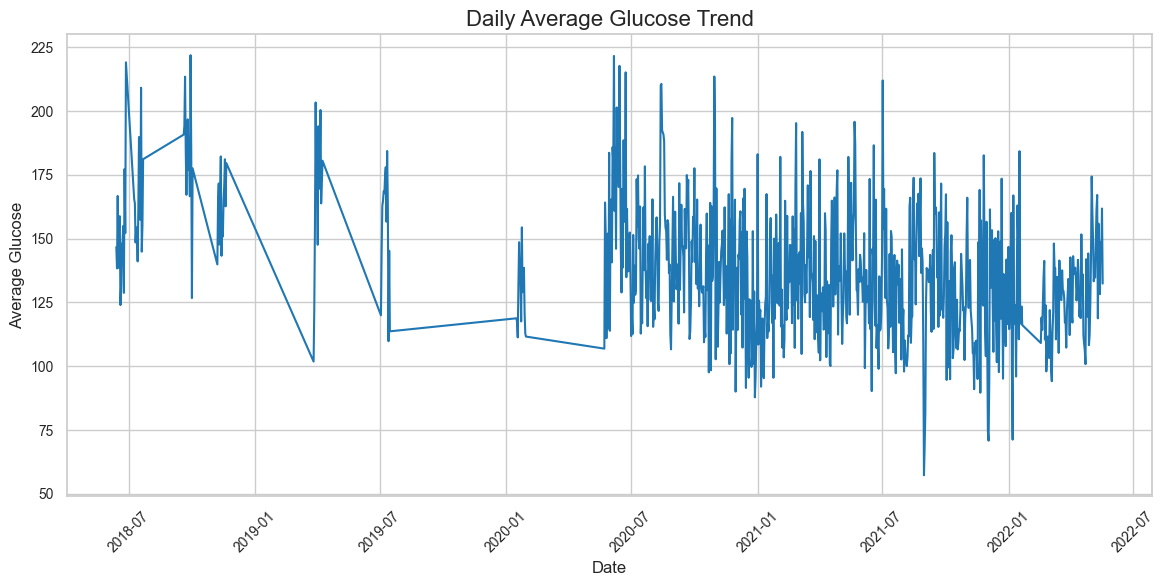

In [17]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_glucose_summary,
    x="date",
    y="average_glucose"
)

plt.title("Daily Average Glucose Trend")
plt.xlabel("Date")
plt.ylabel("Average Glucose")
plt.xticks(rotation=45)
plt.show()

## Section D: Patient-Level Descriptive Analysis
### 12. Patient Summary Review

Why this step is important

Patient-level summaries help compare individual patient glucose behavior.

Consequences if skipped

The project may only show overall patterns and miss patient-specific differences.

In [18]:
patient_summary.head()

,patient_id,start_time,end_time,total_records,avg_glucose,min_glucose,max_glucose,low_glucose_events,high_glucose_events
0,HUPA0001P,2018-06-13 18:40:00,2018-06-27 23:55:00,4096,181.443726,40.0,444.0,59,1723
1,HUPA0002P,2018-06-13 22:45:00,2018-06-24 23:45:00,3181,113.469664,40.0,310.0,759,466
2,HUPA0003P,2018-06-13 21:40:00,2018-06-26 23:45:00,3770,143.273519,44.0,366.0,265,954
3,HUPA0004P,2018-07-09 15:30:00,2018-07-20 16:45:00,3184,180.377984,40.0,411.0,309,1448
4,HUPA0005P,2018-07-09 14:20:00,2018-07-22 23:45:00,3858,147.698624,40.0,379.0,114,973


In [19]:
patient_summary.describe()

,total_records,avg_glucose,min_glucose,max_glucose,low_glucose_events,high_glucose_events
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,12375.680000,155.312205,44.000000,364.180000,815.080000,2684.920000
std,32975.073076,26.123717,12.186058,54.345515,2112.864799,5237.774018
min,2290.000000,112.550584,40.000000,245.000000,0.000000,230.000000
25%,3184.000000,135.892648,40.000000,310.000000,111.000000,809.000000
50%,3829.000000,159.108579,40.000000,370.000000,226.000000,1272.000000
75%,3919.000000,173.151991,42.000000,401.000000,581.000000,1743.000000
max,165306.000000,200.795244,100.000000,444.000000,10520.000000,23427.000000


### 13. Average Glucose by Patient

Why this step is important

This chart identifies patients with higher or lower average glucose levels.

Consequences if skipped

Patient-level differences may remain hidden.

Dashboard use

This can support a patient comparison tab.

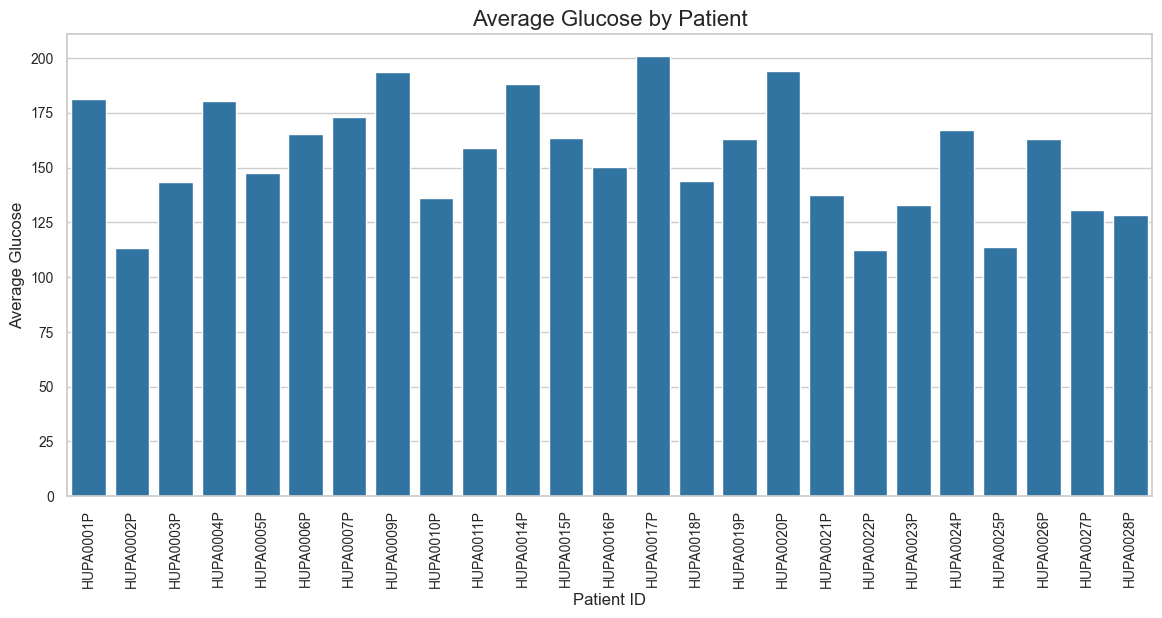

In [20]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=patient_summary,
    x="patient_id",
    y="avg_glucose"
)

plt.title("Average Glucose by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Average Glucose")
plt.xticks(rotation=90)
plt.show()

### 14. Glucose Range by Patient

Why this step is important

Glucose range shows variability between each patient's minimum and maximum readings.

Consequences if skipped

A patient with normal average glucose but extreme fluctuations may be overlooked.

Dashboard use

This can help identify patients with unstable glucose patterns.

In [21]:
patient_summary["glucose_range"] = (
    patient_summary["max_glucose"] - patient_summary["min_glucose"]
)

patient_summary[["patient_id", "min_glucose", "max_glucose", "glucose_range"]].head()

,patient_id,min_glucose,max_glucose,glucose_range
0,HUPA0001P,40.0,444.0,404.0
1,HUPA0002P,40.0,310.0,270.0
2,HUPA0003P,44.0,366.0,322.0
3,HUPA0004P,40.0,411.0,371.0
4,HUPA0005P,40.0,379.0,339.0


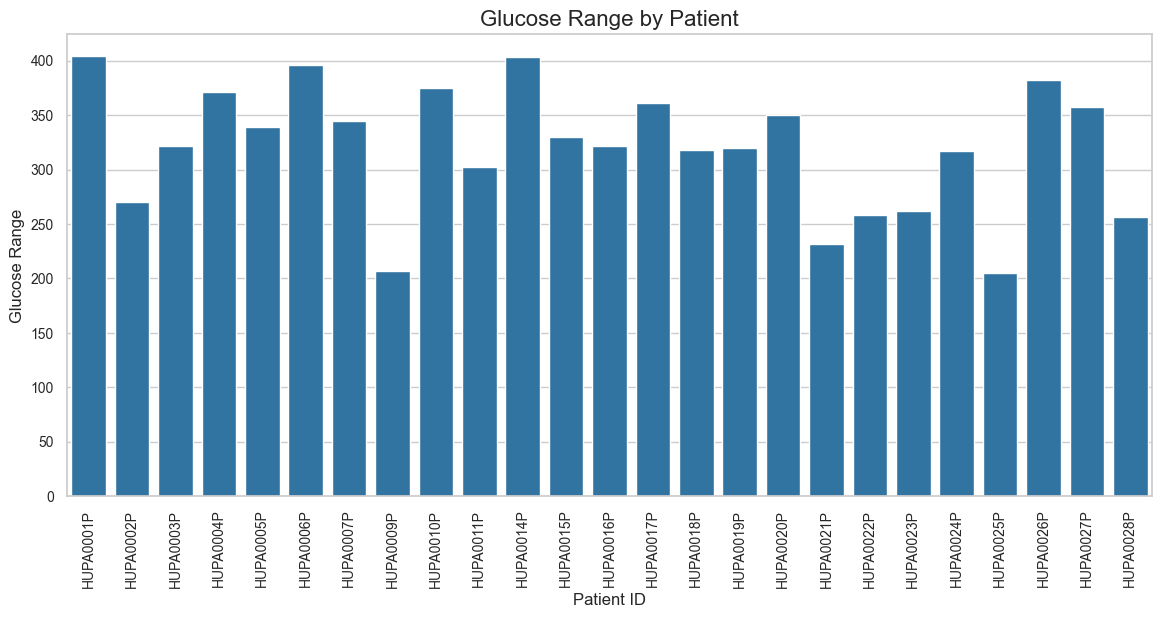

In [22]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=patient_summary,
    x="patient_id",
    y="glucose_range"
)

plt.title("Glucose Range by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Glucose Range")
plt.xticks(rotation=90)
plt.show()

## Section E: Risk-Based Descriptive Analysis
### 15. High Glucose Readings by Hour

Why this step is important

This identifies the hours when high glucose readings occur most often.

Consequences if skipped

The project may miss important high-risk time windows.

Dashboard use

This can support alert-style recommendations in the dashboard.

In [23]:
high_glucose_df = df[df["glucose_category"].isin(["High", "Very High"])]

high_glucose_by_hour = (
    high_glucose_df.groupby("hour")
    .size()
    .reset_index(name="high_glucose_count")
)

high_glucose_by_hour.head()

,hour,high_glucose_count
0,0,2845
1,1,2405
2,2,2399
3,3,2579
4,4,2760


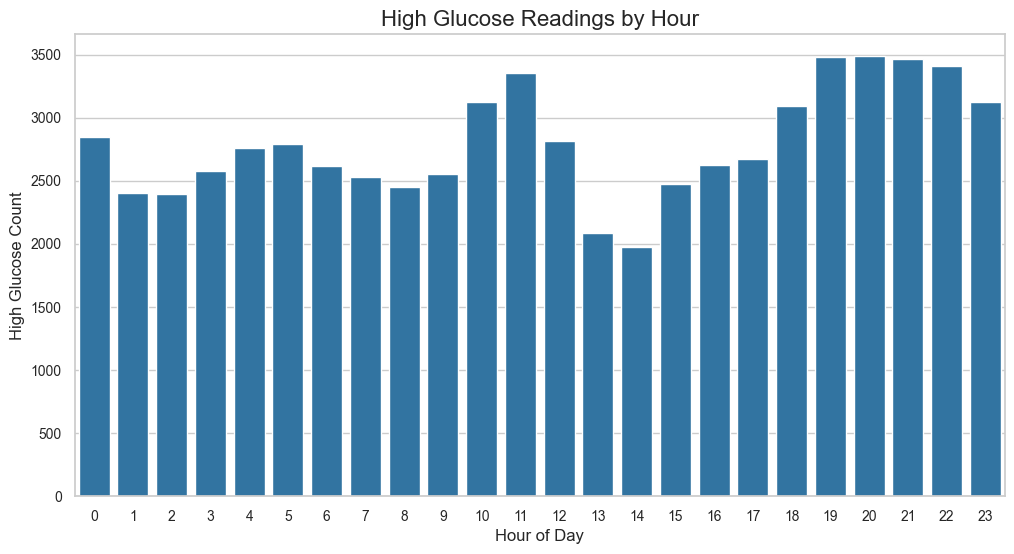

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=high_glucose_by_hour,
    x="hour",
    y="high_glucose_count"
)

plt.title("High Glucose Readings by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("High Glucose Count")
plt.show()

### 16. Low Glucose Readings by Hour

Why this step is important

Low glucose readings are important because they may indicate hypoglycemia risk.

Consequences if skipped

The analysis may focus only on high glucose and ignore low glucose risk.

In [25]:
low_glucose_df = df[df["glucose_category"] == "Low"]

low_glucose_by_hour = (
    low_glucose_df.groupby("hour")
    .size()
    .reset_index(name="low_glucose_count")
)

low_glucose_by_hour.head()

,hour,low_glucose_count
0,0,750
1,1,821
2,2,952
3,3,1089
4,4,1097


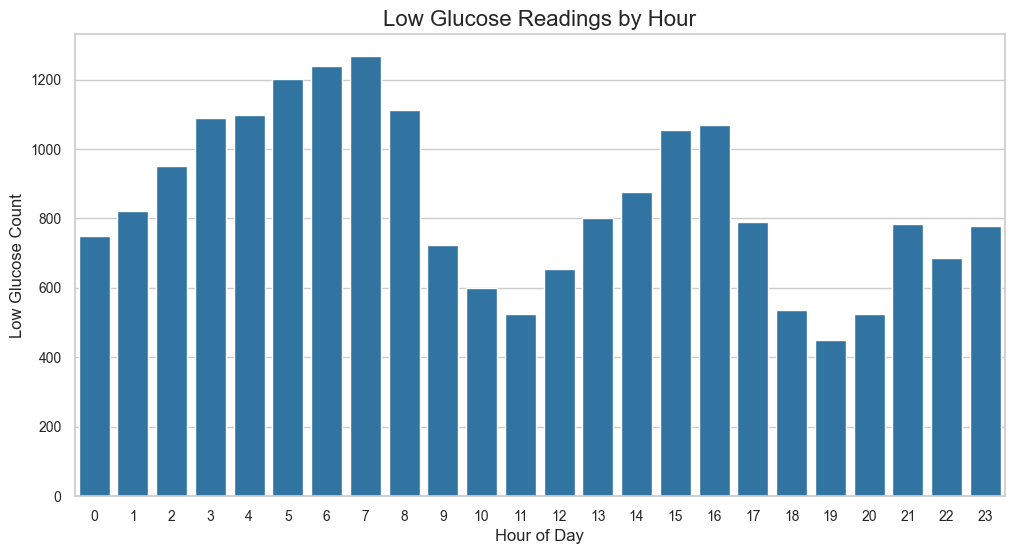

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=low_glucose_by_hour,
    x="hour",
    y="low_glucose_count"
)

plt.title("Low Glucose Readings by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Low Glucose Count")
plt.show()

### 17. Risk Category by Patient

Why this step is important

This summarizes glucose risk categories for each patient.

Consequences if skipped

We may not know which patients have more frequent low or high glucose events.

Dashboard use

This table can be used for patient-level risk comparison.

In [27]:
patient_risk_summary = (
    df.groupby(["patient_id", "glucose_category"])
    .size()
    .reset_index(name="count")
)

patient_risk_summary.head()

,patient_id,glucose_category,count
0,HUPA0001P,High,1723
1,HUPA0001P,Low,59
2,HUPA0001P,Normal,2314
3,HUPA0002P,High,466
4,HUPA0002P,Low,759


In [28]:
patient_risk_pivot = patient_risk_summary.pivot_table(
    index="patient_id",
    columns="glucose_category",
    values="count",
    fill_value=0
).reset_index()

patient_risk_pivot.head()

glucose_category,patient_id,High,Low,Normal
0,HUPA0001P,1723.0,59.0,2314.0
1,HUPA0002P,466.0,759.0,1956.0
2,HUPA0003P,954.0,265.0,2551.0
3,HUPA0004P,1448.0,309.0,1427.0
4,HUPA0005P,973.0,114.0,2771.0


## Section F: Activity and Lifestyle Descriptive Summary
### 18. Activity 

Why this step is important

This summarizes lifestyle-related variables that may influence glucose behavior.

Consequences if skipped

The analysis may ignore useful context around activity, calories, and heart rate.

In [29]:
activity_summary = df[[
    "steps",
    "calories",
    "heart_rate",
    "glucose"
]].describe()

activity_summary

,steps,calories,heart_rate,glucose
count,309392.000000,309392.000000,309392.000000,309392.000000
mean,30.825005,8.813568,76.990001,141.425051
std,84.981109,6.930449,15.546699,57.085587
min,0.000000,0.000000,32.407773,40.000000
25%,0.000000,5.846100,64.930233,99.666667
50%,0.000000,6.278100,75.418726,132.000000
75%,11.000000,9.193060,85.612685,173.000000
max,842.000000,106.350000,195.615385,444.000000


### 19. Average Glucose by Activity Level

Why this step is important

This gives a descriptive view of glucose levels across different activity levels.

Consequences if skipped

Potential lifestyle-related patterns may not be summarized.

Dashboard use

This can support a prescriptive insight such as comparing glucose during low and high activity periods.

In [30]:
df["activity_level"] = pd.cut(
    df["steps"],
    bins=[-1, 0, 50, 200, df["steps"].max()],
    labels=["No Activity", "Low Activity", "Moderate Activity", "High Activity"]
)

activity_glucose_summary = (
    df.groupby("activity_level", observed=False)
    .agg(
        average_glucose=("glucose", "mean"),
        median_glucose=("glucose", "median"),
        reading_count=("glucose", "count")
    )
    .reset_index()
)

activity_glucose_summary

,activity_level,average_glucose,median_glucose,reading_count
0,No Activity,138.257715,129.666667,219350
1,Low Activity,147.594378,137.333333,43538
2,Moderate Activity,151.206328,141.000000,31965
3,High Activity,149.231397,139.000000,14539


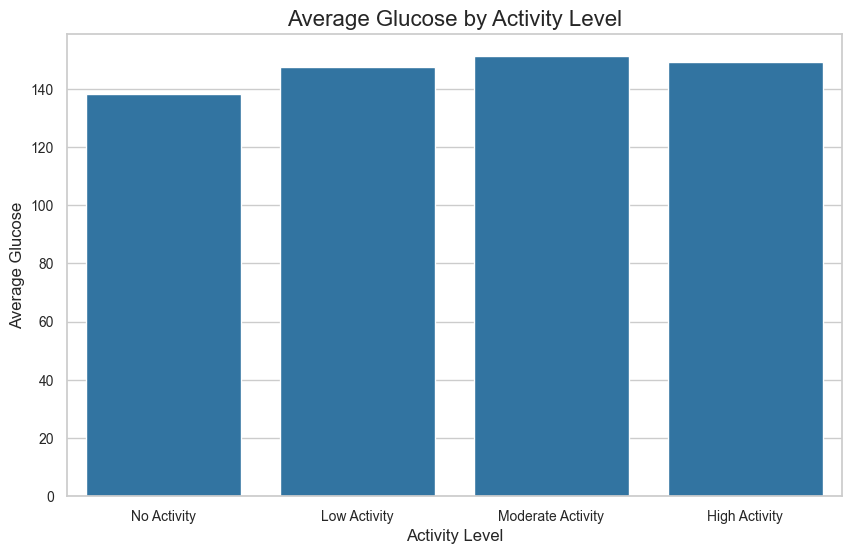

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=activity_glucose_summary,
    x="activity_level",
    y="average_glucose"
)

plt.title("Average Glucose by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Average Glucose")
plt.show()

## Section G: Dashboard-Ready Output Files
### 20. Create Output Folder

Why this step is important

The output folder stores reusable summary files for the dashboard and future notebooks.

Consequences if skipped

Exported files may fail to save if the folder does not exist.

In [32]:
OUTPUT_DIR = "../outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

### 21. Save Descriptive Analysis Outputs

Why this step is important

Saving summary outputs makes the project more organized and prepares data for the Streamlit dashboard.

Consequences if skipped

Dashboard development may require repeating the same calculations again.

In [33]:
kpi_summary.to_csv(
    os.path.join(OUTPUT_DIR, "descriptive_kpi_summary.csv"),
    index=False
)

glucose_category_counts.to_csv(
    os.path.join(OUTPUT_DIR, "glucose_category_counts.csv"),
    index=False
)

glucose_category_percent.to_csv(
    os.path.join(OUTPUT_DIR, "glucose_category_percentages.csv"),
    index=False
)

hourly_glucose_summary.to_csv(
    os.path.join(OUTPUT_DIR, "hourly_glucose_summary.csv"),
    index=False
)

weekday_glucose_summary.to_csv(
    os.path.join(OUTPUT_DIR, "weekday_glucose_summary.csv"),
    index=False
)

daily_glucose_summary.to_csv(
    os.path.join(OUTPUT_DIR, "daily_glucose_summary.csv"),
    index=False
)

patient_summary.to_csv(
    os.path.join(OUTPUT_DIR, "patient_descriptive_summary.csv"),
    index=False
)

patient_risk_pivot.to_csv(
    os.path.join(OUTPUT_DIR, "patient_risk_summary.csv"),
    index=False
)

activity_glucose_summary.to_csv(
    os.path.join(OUTPUT_DIR, "activity_glucose_summary.csv"),
    index=False
)

print("All descriptive analysis output files saved successfully.")

All descriptive analysis output files saved successfully.


## Descriptive Analysis Summary

This notebook summarized the cleaned diabetes glucose dataset using KPI metrics, trend analysis, patient-level summaries, risk category analysis, and activity-based summaries.

### Key Findings

1. Overall glucose KPIs were calculated, including average, median, minimum, and maximum glucose.
2. Glucose readings were summarized by category to understand low, normal, and high-risk glucose patterns.
3. Hourly glucose analysis showed how glucose levels vary throughout the day.
4. Daily glucose trends provided a time-based view of glucose behavior.
5. Patient-level summaries showed differences in average glucose and glucose variability.
6. High and low glucose readings were summarized by hour to identify risk-prone time windows.
7. Activity-level summaries were created to compare glucose patterns across different step activity groups.

### Dashboard-Ready Outputs Created

The following files were saved in the outputs folder:

- descriptive_kpi_summary.csv
- glucose_category_counts.csv
- glucose_category_percentages.csv
- hourly_glucose_summary.csv
- weekday_glucose_summary.csv
- daily_glucose_summary.csv
- patient_descriptive_summary.csv
- patient_risk_summary.csv
- activity_glucose_summary.csv

### Connection to Next Notebook

The next notebook should focus on prescriptive analysis.

Prescriptive analysis will use these descriptive findings to create action-oriented recommendations such as:

- identifying high-risk glucose hours
- identifying patients with unstable glucose patterns
- suggesting dashboard alerts
- creating patient risk groups
- preparing recommendation logic